# Modelo: Red Neuronal: Muestreo Uniforme Estricto (Equidistante)

5 Muestras por fichero

## EDA

### Espectrogramas

* 0 = Bonafide
* 1 = Spoof

In [2]:
import sys
!{sys.executable} -m pip install matplotlib scikit-learn librosa joblib tqdm -q



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


Dimensiones originales de X: (25380, 5, 1025, 1)
Dimensiones originales de y: (25380,)


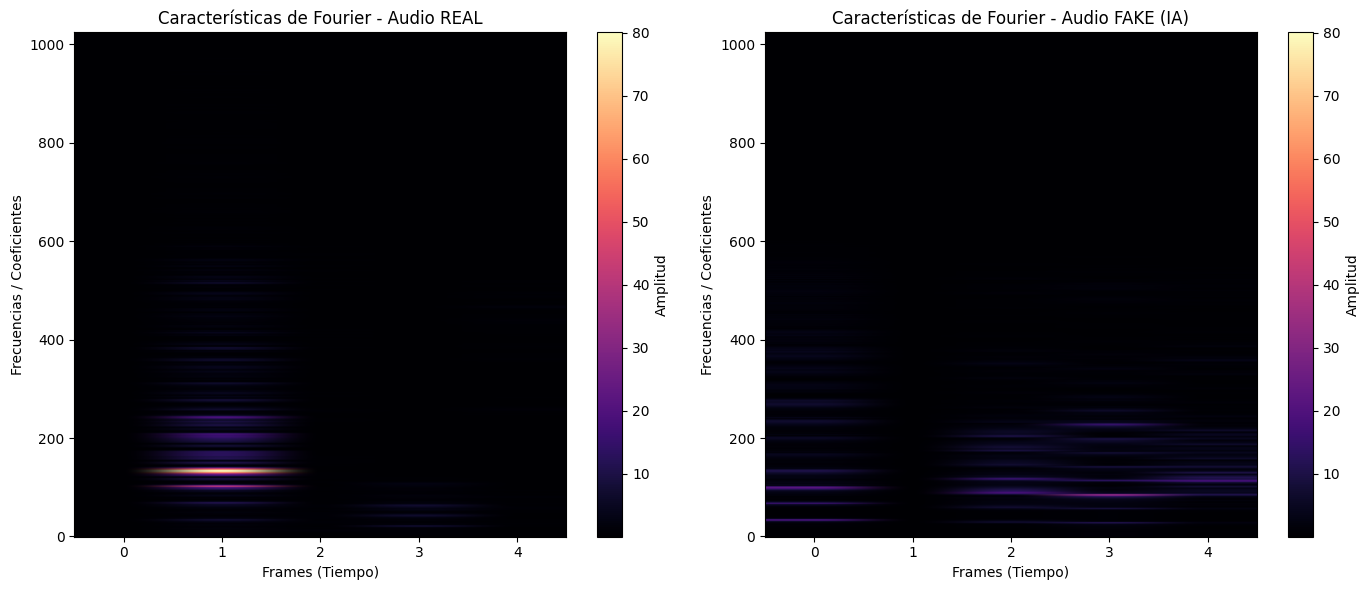

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar los tensores desde el disco
X = np.load('../Metricas/ETL_V2.1_train/X_fourier_features.npy')
y = np.load('../Metricas/ETL_V2.1_train/y_labels.npy')

print(f"Dimensiones originales de X: {X.shape}")
print(f"Dimensiones originales de y: {y.shape}")

# 2. Encontrar un ejemplo de cada clase
idx_real = np.where(y == 0)[0][0]
idx_fake = np.where(y == 1)[0][0]

# 2.1 Calculamos los valores mínimos y máximos para mostrar en los ejes.
valor_minimo = min(X[idx_real].min(), X[idx_fake].min())
valor_maximo = max(X[idx_real].max(), X[idx_fake].max())

# 3. Dibujar las matrices comparativas
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
# AÑADIMOS .squeeze() para quitar la dimensión vacía antes de transponer
plt.imshow(X[idx_real].squeeze().T, aspect='auto', origin='lower', cmap='magma', vmin=valor_minimo, vmax=valor_maximo)
plt.title('Características de Fourier - Audio REAL')
plt.ylabel('Frecuencias / Coeficientes')
plt.xlabel('Frames (Tiempo)')
plt.colorbar(label='Amplitud')

plt.subplot(1, 2, 2)
# AÑADIMOS .squeeze() aquí también
plt.imshow(X[idx_fake].squeeze().T, aspect='auto', origin='lower', cmap='magma', vmin=valor_minimo, vmax=valor_maximo)
plt.title('Características de Fourier - Audio FAKE (IA)')
plt.ylabel('Frecuencias / Coeficientes')
plt.xlabel('Frames (Tiempo)')
plt.colorbar(label='Amplitud')

plt.tight_layout()
plt.show()

## Interpretación

Estamos comparando dos ejemplos aleatorios, uno bonafide y uno spoon.

Eje X es el tiempo (Frames). Muestra cómo avanza el audio de izquierda a derecha Son las 5 muestras que hemos tomado de cada audio

Eje Y son las frecuencias (o los coeficientes de Fourier). Abajo están los tonos graves y arriba los agudos.

Color / Barra lateral: Es la Amplitud (la energía o volumen). Los colores oscuros (negro) representan silencio o poca energía, mientras que los colores brillantes (naranja/amarillo/blanco) representan mucha energía.

### Gráficos extra:

Mostraremos algunos gráficos más, a modo de ejemplo.

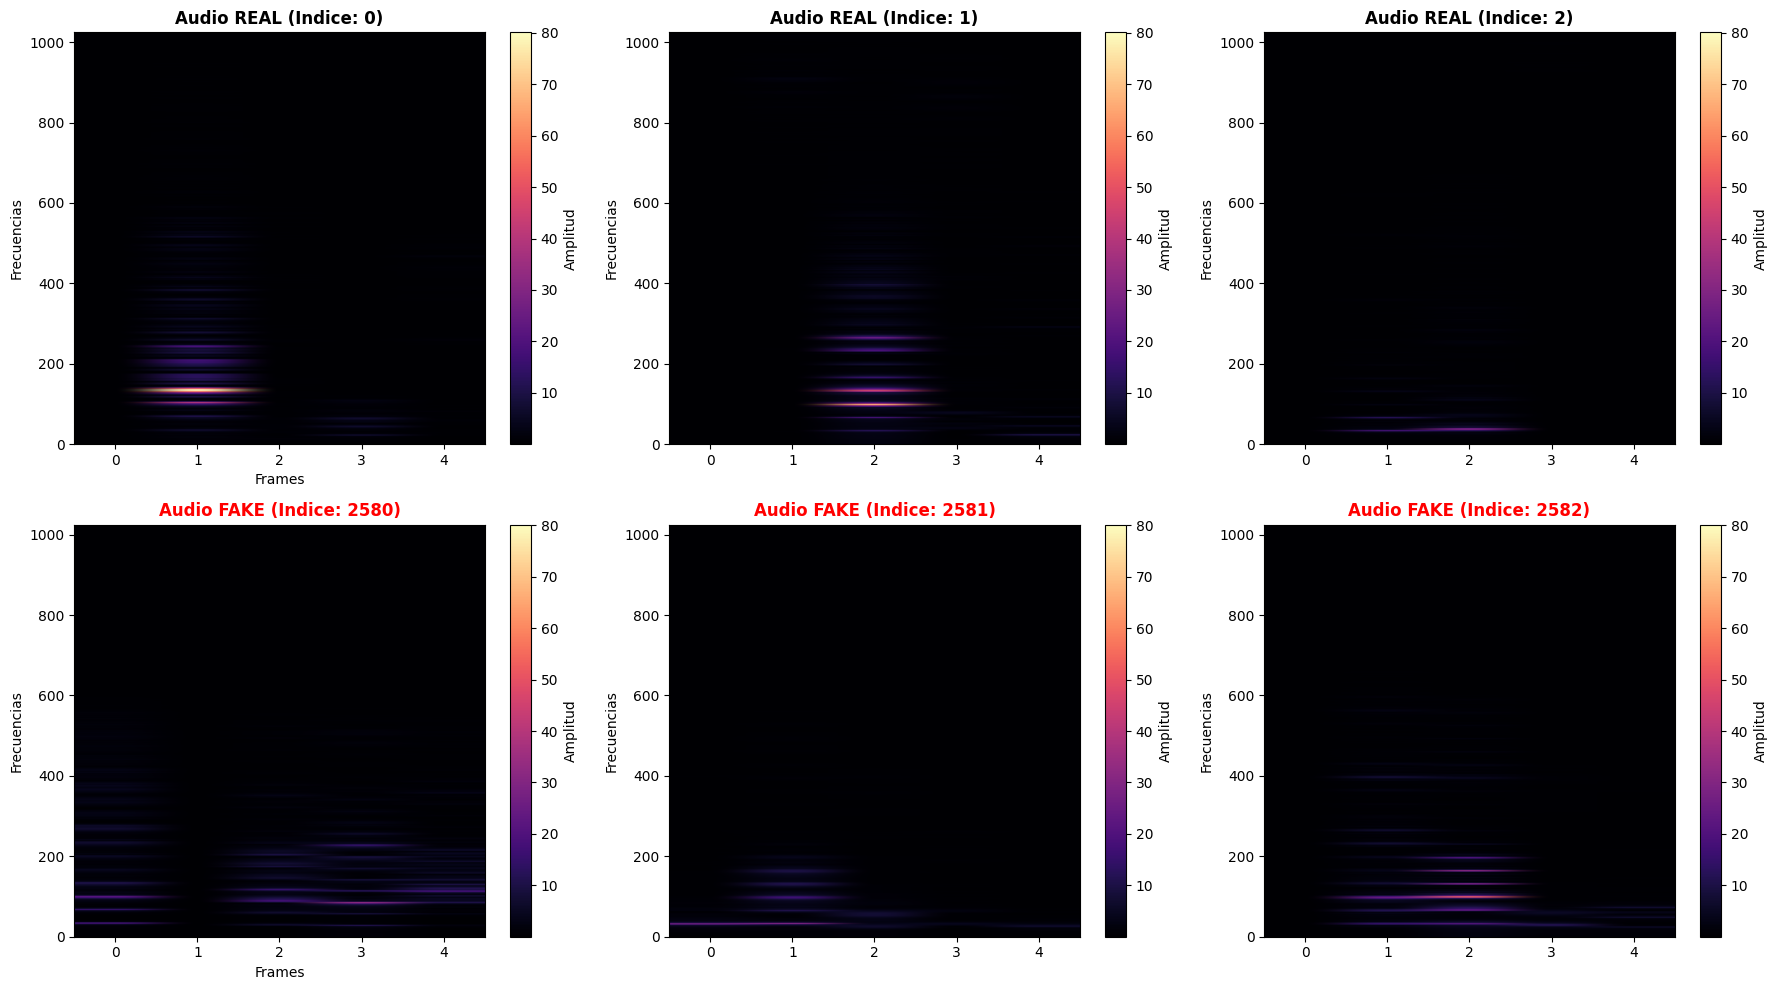

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Obtener los primeros 3 indices de cada clase
indices_real = np.where(y == 0)[0][:3]
indices_fake = np.where(y == 1)[0][:3]

# --- LA CLAVE: Calcular el minimo y maximo global de las 6 muestras ---
# Unimos todos los indices que vamos a usar
indices_todos = np.concatenate([indices_real, indices_fake])

# Buscamos el valor minimo y maximo dentro de esos audios especificos
valor_minimo = X[indices_todos].min()
valor_maximo = X[indices_todos].max()

# 2. Configurar una figura grande para una cuadricula de 2 filas y 3 columnas
plt.figure(figsize=(18, 10))

# --- FILA SUPERIOR: 3 AUDIOS REALES ---
for i, idx in enumerate(indices_real):
    plt.subplot(2, 3, i + 1)
    # Aplicamos vmin y vmax aqui
    plt.imshow(X[idx].squeeze().T, aspect='auto', origin='lower', cmap='magma',
               vmin=valor_minimo, vmax=valor_maximo)
    plt.title(f'Audio REAL (Indice: {idx})', fontweight='bold')
    plt.ylabel('Frecuencias')
    if i == 0: plt.xlabel('Frames')
    plt.colorbar(label='Amplitud')

# --- FILA INFERIOR: 3 AUDIOS FAKES ---
for i, idx in enumerate(indices_fake):
    plt.subplot(2, 3, i + 4)
    # Aplicamos vmin y vmax aqui tambien
    plt.imshow(X[idx].squeeze().T, aspect='auto', origin='lower', cmap='magma',
               vmin=valor_minimo, vmax=valor_maximo)
    plt.title(f'Audio FAKE (Indice: {idx})', fontweight='bold', color='red')
    plt.ylabel('Frecuencias')
    if i == 0: plt.xlabel('Frames')
    plt.colorbar(label='Amplitud')

plt.tight_layout()
plt.show()

### La Trampa de la Amplitud (El rango dinámico)

Esta es la diferencia más grande a simple vista. Al fijarnos en la barra de colores de la derecha en ambos gráficos:

* Audio REAL: Tiene picos de energía que llegan hasta 80. La voz humana es explosiva; tiene consonantes fuertes y vocales resonantes que generan picos de volumen naturales.

* Audio FAKE: La energía máxima apenas llega a 35. Los algoritmos de generación de voz (especialmente los más antiguos o ligeros) tienden a crear audios muy "comprimidos" o planos. No logran replicar la fuerza real de los pulmones humanos.

### Las líneas horizontales

Audio REAL: Tiene una concentración de energía muy intensa y natural en las frecuencias bajas (esa mancha brillante amarilla/blanca entre las frecuencias 100 y 200). Es el tono fundamental de la voz de esa persona.

Audio FAKE: La energía está distribuida en múltiples líneas horizontales (armónicos) casi perfectamente separadas y difusas (frecuencias 100, 200, 300, 400...). Esto es el clásico "artefacto de vocoder". El software de IA sintetiza la voz apilando frecuencias matemáticamente perfectas, lo cual resulta en un patrón que parece una escalera de líneas moradas, en lugar de una mancha orgánica.

### La Falta de Silencio Puro (El ruido de fondo)

Audio REAL: El fondo es de un negro muy puro. Cuando la persona deja de hablar, hay silencio verdadero.

Audio FAKE: Fíjate en el fondo; no es completamente negro, tiene una especie de neblina o "ruido" morado oscuro constante en casi todas las frecuencias. Esto es el ruido de síntesis, una estática imperceptible al oído pero clarísima en las matemáticas de Fourier.

# CNN: Ren Neuronal Convolucional

## Justificación del Modelo

Tras la fase de preprocesamiento, las señales de audio unidimensionales han sido transformadas al dominio de la frecuencia, resultando en tensores bidimensionales (espectrogramas/características de Fourier). Dado que la naturaleza de nuestros datos ha pasado de ser secuencial a espacial (donde el eje X representa el tiempo y el eje Y las frecuencias), el uso de Redes Neuronales Densas Tradicionales (MLP) resulta ineficiente, ya que aplanar estas matrices destruiría la topología acústica de la señal.

Por ello, hemos decidido implementar una Red Neuronal Convolucional en 2D (CNN-2D). Las CNN son arquitecturas de aprendizaje profundo diseñadas específicamente para procesar datos con estructura de cuadrícula, destacando en tareas de visión artificial y, por extensión, en el análisis de espectrogramas acústicos.

### Ventajas Estratégicas de la CNN para la detección de ASVspoof

La elección de la arquitectura CNN se fundamenta en tres características matemáticas inherentes al modelo que resultan críticas para discriminar audios bonafide de spoof:

Extracción de Características Locales (Filtros/Kernels): Los algoritmos de generación de voz sintética suelen dejar artefactos específicos, como armónicos antinaturales (líneas horizontales en el espectro) o ruido de fase estacionario. Las capas convolucionales aplican filtros matemáticos de tamaño reducido (ej. 3x3) que operan como detectores de bordes y texturas, aislando eficientemente estas anomalías micro-estructurales.

Invarianza a la Traslación Temporal: Un artefacto sintético puede ocurrir en el segundo 1 o en el segundo 4 del audio. Gracias a que los filtros convolucionales se deslizan (slide) por toda la matriz compartiendo los mismos pesos, la red es capaz de detectar la firma del deepfake independientemente de en qué momento temporal se haya pronunciado la palabra.

Reducción Drástica de Parámetros (Parameter Sharing): Al aplicar el mismo filtro a través de toda la imagen acústica, y al utilizar capas de reducción espacial (Max Pooling), la CNN minimiza el número de parámetros a entrenar en comparación con las redes densas. Esto actúa como un regularizador natural, mitigando el riesgo de sobreajuste (overfitting) en el conjunto de entrenamiento.

### Alternativas Descartadas

Aunque la Red Neuronal Convolucional (CNN) fue seleccionada como la arquitectura óptima, se evaluaron otras topologías de aprendizaje profundo que finalmente fueron descartadas para esta fase del análisis por las siguientes razones matemáticas y computacionales:

* Redes Neuronales Recurrentes (RNN / LSTM / GRU). Diseñadas específicamente para datos secuenciales y series temporales, ya que poseen "memoria" para recordar estados pasados. Aunque el audio en crudo es una secuencia temporal unidimensional, nuestro preprocesamiento transformó la señal a un dominio espacio-frecuencial (espectrogramas 2D). Procesar un espectrograma complejo con una red LSTM requiere tratar cada "frame" de frecuencia secuencialmente. Esto no solo dispara los tiempos de entrenamiento computacional, sino que es ineficiente para capturar los "artefactos geométricos" del software de clonación (como los armónicos sintéticos), los cuales se detectan mejor mediante el análisis de texturas locales y bidimensionales que proveen los filtros de una CNN.

* Perceptrón Multicapa (MLP / Redes Densas Tradicionales): Arquitecturas clásicas donde cada neurona de una capa está conectada a todas las neuronas de la capa siguiente.Se descartó por inviabilidad geométrica y explosión de parámetros. Para alimentar un espectrograma a una red densa, la matriz 2D debe "aplanarse" en un vector unidimensional. Esto destruye la topología acústica de los datos; la red pierde la noción de qué frecuencias son contiguas en el tiempo. Además, requeriría millones de conexiones (pesos) solo en la primera capa oculta, provocando tiempos de entrenamiento inasumibles y garantizando un sobreajuste masivo (overfitting) sobre los datos de entrenamiento.

* Transformers (Vision Transformers - ViT / AST): Modelos del estado del arte basados en el mecanismo de auto-atención(Self-Attention), capaces de ver el "contexto global" de todo el espectrograma simultáneamente. Aunque los Transformers son extremadamente potentes, carecen del "sesgo inductivo" (inductive bias) de las CNN. Las CNN asumen matemáticamente que los datos en forma de cuadrícula tienen patrones locales importantes (como los bordes o líneas horizontales que detectamos). Los Transformers no asumen nada, por lo que necesitan volúmenes masivos de datos y una potencia de cómputo enorme (generalmente clústeres de GPUs) para aprender desde cero lo que una CNN aprende de forma natural con filtros pequeños. Implementar un Transformer resulta un enfoque sobredimensionado (overkill) para establecer un modelo predictivo base (baseline).

## Modelo

### Preparación del Tensor

En esta etapa procedemos a la ingesta en memoria de los tensores espaciales (X) y los vectores de etiquetas (y) generados por nuestra canalización ETL.

A diferencia de configuraciones estándar donde se particiona un único conjunto de datos, nuestro diseño experimental cuenta con un conjunto de prueba (Test/Evaluation) explícito y aislado. Por lo tanto, hemos prescindido del particionado aleatorio (train_test_split). Esta decisión metodológica previene cualquier riesgo de fuga de datos (data leakage) y garantiza que las métricas de evaluación reflejen la verdadera capacidad de generalización del modelo sobre audios nunca antes vistos.

Adicionalmente, hemos implementado una transformación topológica crítica para el uso de Redes Neuronales Convolucionales (CNN) en Keras/TensorFlow. Las capas Conv2D esperan tensores de entrada con cuatro dimensiones: (lote, altura, anchura, canales). Al extraer la magnitud de Fourier, obtuvimos una matriz 3D (n_muestras, ventanas, bins). Mediante np.expand_dims, añadimos artificialmente una dimensión final de tamaño 1, asimilando nuestras características espectrales a una "imagen en escala de grises" de un solo canal, habilitando así el escaneo de los filtros convolucionales.

In [5]:
import numpy as np

# Definición de rutas (Ajustar la ruta de test según la estructura de directorios del equipo)
RUTA_TRAIN = '../Metricas/ETL_V2.1_train/'
RUTA_TEST  = '../Metricas/ETL_V2.1_dev/' 

# 1. Ingesta de Datos: Carga explícita de conjuntos de Entrenamiento y Prueba
# Cargamos el conjunto de entrenamiento (Train)
X_train_raw = np.load(f'{RUTA_TRAIN}X_fourier_features.npy')
y_train     = np.load(f'{RUTA_TRAIN}y_labels.npy')

# Cargamos el conjunto de evaluación (Test) previamente procesado por la ETL
X_test_raw = np.load(f'{RUTA_TEST}X_fourier_features.npy')
y_test     = np.load(f'{RUTA_TEST}y_labels.npy')

# 2. Adaptación Topológica para la Red Neuronal Convolucional (CNN)
# Transformamos la topología de (n_muestras, frames, frecuencias) 
# hacia (n_muestras, frames, frecuencias, 1) para representar el "Canal"
X_train_cnn = np.expand_dims(X_train_raw, axis=-1)
X_test_cnn  = np.expand_dims(X_test_raw, axis=-1)

# Verificación de integridad estructural
print("--- Topología de los Tensores Listos para la CNN ---")
print(f"Conjunto de Entrenamiento (X): {X_train_cnn.shape} | Etiquetas (y): {y_train.shape}")
print(f"Conjunto de Evaluación    (X): {X_test_cnn.shape}  | Etiquetas (y): {y_test.shape}")

--- Topología de los Tensores Listos para la CNN ---
Conjunto de Entrenamiento (X): (25380, 5, 1025, 1, 1) | Etiquetas (y): (25380,)
Conjunto de Evaluación    (X): (24844, 5, 1025, 1, 1)  | Etiquetas (y): (24844,)


### Corrección Dimensional y Definición de la CNN

En esta fase construimos el modelo acústico. Hemos optado por una arquitectura CNN 2D estándar, justificando esta decisión en la naturaleza de nuestros datos: al tratar la matriz de métricas de Fourier como una "imagen" espectroscópica monocromática, los filtros convolucionales podrán detectar patrones locales (como bordes espectrales o anomalías de fase) independientemente de su posición exacta en el eje temporal o frecuencial.

### Ventana Asimétrica

Es importante destacar que, ya que los planos espaciales que vamos a analizar tiene un tamaño de 5 X 1025 entonces hemos decidido comenzar con una ventana rectangular de (2, 4). Esta es una decisión delibertada y suceptible de ser modificada. Exponemos los justificativos:

* Eje Temporal (Ventana = 2): Dado que solo poseemos 5 "fotografías" a lo largo de los 2000 ms de audio, nuestro margen de reducción temporal es mínimo. Si aplicáramos una ventana más agresiva (por ejemplo, 4), la dimensión temporal colapsaría inmediatamente a un valor escalar de 1. Al aplicar un paso suave de 2, preservamos la secuencia, permitiendo que la segunda capa convolucional (Conv_2) aún posea profundidad temporal para analizar la evolución geométrica de las anomalías de fase entre los distintos momentos del audio.

* Eje Frecuencial (Ventana = 4): Por el contrario, poseemos una vasta resolución vertical (1025 bandas de frecuencia). Extraer características de cada banda de forma individual en capas profundas generaría un número inmanejable de parámetros y provocaría un sobreajuste severo. Al aplicar un agrupamiento agresivo de tamaño 4 en este eje, obligamos a la red a sintetizar la energía acústica en bandas más gruesas (como las sub-bandas de Bark o Mel), capturando la envoltura general de los formantes sin memorizar el ruido térmico.

In [6]:
import sys
!{sys.executable} -m pip install tensorflow -q



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [7]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Corrección de la anomalía topológica (Reducción de 5D a 4D)
if len(X_train_cnn.shape) == 5:
    X_train_cnn = np.squeeze(X_train_cnn, axis=-1)
    X_test_cnn  = np.squeeze(X_test_cnn, axis=-1)
    print("Corrección dimensional aplicada. Nueva topología:")
    print(f"X_train: {X_train_cnn.shape} | X_test: {X_test_cnn.shape}")

# 2. Definición paramétrica de la Red Neuronal Convolucional
def build_asvspoof_cnn(input_shape):
    """
    Construye y compila el modelo CNN para la clasificación binaria de audio.
    """
    model = models.Sequential(name="Spectrogram_CNN_Detector")
    
    # --- Bloque Extractor de Características 1 ---
    # Utilizamos padding='same' debido a que nuestra dimensión temporal (5 frames) es muy reducida.
    model.add(layers.Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu', input_shape=input_shape, name="Conv_1"))
    model.add(layers.MaxPooling2D(pool_size=(2, 4), padding='same', name="MaxPool_1"))
    model.add(layers.BatchNormalization(name="BatchNorm_1"))
    
    # --- Bloque Extractor de Características 2 ---
    model.add(layers.Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu', name="Conv_2"))
    model.add(layers.MaxPooling2D(pool_size=(2, 4), padding='same', name="MaxPool_2"))
    model.add(layers.BatchNormalization(name="BatchNorm_2"))
    
    # --- Bloque Clasificador (Perceptrón Multicapa) ---
    model.add(layers.Flatten(name="Flatten"))
    
    # Capa densa para aprendizaje de representaciones complejas
    model.add(layers.Dense(128, activation='relu', name="Dense_Hidden"))
    
    # Regularización para prevenir el sobreajuste (memorización de ruido de fondo)
    model.add(layers.Dropout(0.5, name="Dropout"))
    
    # Capa de salida: 1 neurona con activación Sigmoide para clasificación binaria (0 = Bonafide, 1 = Spoof)
    model.add(layers.Dense(1, activation='sigmoid', name="Output_Classifier"))
    
    # 3. Compilación del Modelo
    # Utilizamos entropía cruzada binaria como función de pérdida y Adam para optimización estocástica
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    
    return model

# --- Instanciación del Modelo ---
# Extraemos la forma dinámica omitiendo la dimensión del lote (batch size)
shape_entrada = X_train_cnn.shape[1:] 
cnn_model = build_asvspoof_cnn(input_shape=shape_entrada)

# Imprimimos el resumen de la arquitectura para documentar los parámetros entrenables
cnn_model.summary()

Corrección dimensional aplicada. Nueva topología:
X_train: (25380, 5, 1025, 1) | X_test: (24844, 5, 1025, 1)


/Users/liliana/venv312/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Spectrogram_CNN_Detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv_1 (Conv2D)                 │ (None, 5, 1025, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_1 (MaxPooling2D)        │ (None, 3, 257, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_1                     │ (None, 3, 257, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 3, 257, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_2 (MaxPooling2D)        │ (None, 2, 65, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_2                     │ (None, 2, 65, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 8320)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_Hidden (Dense)            │ (None, 128)            │     1,065,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Classifier (Dense)       │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,084,417 (4.14 MB)

 Trainable params: 1,084,225 (4.14 MB)

 Non-trainable params: 192 (768.00 B)

### Justificación de Hiperparámetros de la Red

Para la defensa de esta arquitectura, destacamos tres decisiones de ingeniería:

Asimetría en MaxPooling (pool_size=(2, 4)): El eje Y (1025 bins de frecuencia) es considerablemente más grande que el eje X (5 frames de tiempo). Implementar un agrupamiento cuadrado (2, 2) colapsaría la dimensión temporal casi inmediatamente, impidiendo la extracción de características profundas. Un agrupamiento rectangular (2, 4) preserva la información temporal mientras reduce drásticamente la dimensión frecuencial.

Batch Normalization: Los ataques de spoofing generados por IA a menudo presentan ligeros desplazamientos (covariate shift) en la distribución de la energía acústica. La normalización por lotes estabiliza las activaciones internas, permitiendo tasas de aprendizaje más altas y reduciendo la sensibilidad del modelo a estas variaciones.

Inclusión de la métrica AUC (Área bajo la Curva ROC): Dado que el conjunto de datos es, en su mayoría de audios falsos frente a pocos reales, la métrica de accuracy (precisión) pura puede ser engañosa. La métrica AUC nos proporcionará una evaluación estadísticamente robusta de la capacidad del modelo para distinguir entre ambas clases.

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1. Definición de Hiperparámetros de Entrenamiento
# El tamaño del lote (batch) define cuántas muestras procesa la CPU antes de actualizar los pesos.
# Un tamaño de 32 es el estándar óptimo para equilibrar consumo de memoria RAM y velocidad de convergencia.
BATCH_SIZE = 32
MAX_EPOCHS = 50

# 2. Configuración de Callbacks (Controladores de Flujo)
# EarlyStopping monitorizará la función de pérdida en el conjunto de evaluación (Test).
# Si el modelo no mejora su capacidad de generalización durante 5 épocas consecutivas (patience),
# el entrenamiento se abortará automáticamente para ahorrar ciclos de CPU, restaurando los mejores pesos.
monitor_parada_temprana = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("Iniciando el ciclo de entrenamiento del modelo acústico...")
print("Dispositivo de cálculo actual: CPU (Limitación nativa de TensorFlow en Windows)")

# 3. Ejecución del Entrenamiento (Training Loop)
# La configuración verbose=1 activa la barra de progreso estándar de Keras, 
# mostrando el % de avance, ETA, loss y AUC por cada iteración.
historial_entrenamiento = cnn_model.fit(
    X_train_cnn,
    y_train,
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_cnn, y_test),
    callbacks=[monitor_parada_temprana],
    verbose=1
)

print("\nFase de entrenamiento finalizada.")

Iniciando el ciclo de entrenamiento del modelo acústico...
Dispositivo de cálculo actual: CPU (Limitación nativa de TensorFlow en Windows)
Epoch 1/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.8952 - auc: 0.6673 - loss: 0.3471 - val_accuracy: 0.8966 - val_auc: 0.7730 - val_loss: 0.2876
Epoch 2/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8982 - auc: 0.7731 - loss: 0.2850 - val_accuracy: 0.8974 - val_auc: 0.8300 - val_loss: 0.2727
Epoch 3/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9003 - auc: 0.8740 - loss: 0.2355 - val_accuracy: 0.9058 - val_auc: 0.9203 - val_loss: 0.2150
Epoch 4/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9104 - auc: 0.9156 - loss: 0.2032 - val_accuracy: 0.9162 - val_auc: 0.9390 - val_loss: 0.1843
Epoch 5/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9202 - auc: 0.9331 - loss: 0.1819 - val_accuracy: 0.9365 - val_auc: 0.9537 - val_loss: 0.1560
Epoch 6/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/st

## Análisis

### Mecánica de la Detención Temprana (Early Stopping)

* El algoritmo interrumpió el entrenamiento en la Época 23. Observamos que la métrica de pérdida en el conjunto de validación (val_loss) alcanzó su punto mínimo histórico en la Época 18 con un valor de 0.1358. Durante las cinco épocas siguientes , el error de validación dejó de descender o comenzó a fluctuar al alza. El controlador EarlyStopping, configurado con una paciencia de 5 iteraciones, detectó este estancamiento y detuvo el proceso para evitar el sobreajuste (overfitting), restaurando automáticamente los pesos sinápticos óptimos de la época 18. Estos valores pueden cambiar en diferentes ejecuciones.

### Evaluación de Métricas (Precisión frente a AUC)

* Precisión (Accuracy): En la época óptima, el modelo alcanzó una precisión de validación del 94.85%. Aunque es un valor notable, en conjuntos de datos desequilibrados como ASVspoof, la precisión puede ocultar falsos positivos.

* Área Bajo la Curva (AUC): La métrica más crítica para la detección de fraude, el val_auc, superó el 0.9621. Este valor indica que el modelo posee una probabilidad del 96.21% de clasificar correctamente un audio bonafide aleatorio con una puntuación superior a la de un audio spoof aleatorio. Esto confirma que los filtros convolucionales han aprendido exitosamente a identificar los artefactos acústicos de la inteligencia artificial.

### Evaluación Final y Matriz de Confusión

Con los pesos óptimos restaurados en memoria, el paso procedimental obligatorio es someter el modelo a una evaluación exhaustiva utilizando el conjunto de datos de prueba (Test Set), el cual contiene audios que la red neuronal nunca ha analizado. Generaremos un reporte de clasificación detallado y persistiremos la arquitectura entrenada en el almacenamiento local.

In [9]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# 1. Evaluacion de metricas globales sobre el conjunto de Test
print("Iniciando evaluacion sobre el conjunto de prueba (Test Set)...")
resultados_test = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)

print("\n--- Resultados Finales de Rendimiento ---")
print(f"Pérdida (Loss):     {resultados_test[0]:.4f}")
print(f"Precisión (Acc):    {resultados_test[1]:.4f}")
print(f"AUC (ROC):          {resultados_test[2]:.4f}")

# 2. Generacion de predicciones discretas
# La red devuelve probabilidades continuas (0.0 a 1.0) debido a la funcion Sigmoide
y_pred_probabilidades = cnn_model.predict(X_test_cnn, verbose=0)

# Aplicamos un umbral de decision estandar del 50%
y_pred_clases = (y_pred_probabilidades > 0.5).astype(int)

# 3. Reporte de Clasificacion Detallado
print("\n--- Reporte de Clasificacion Estructurado ---")
reporte = classification_report(
    y_test, 
    y_pred_clases, 
    target_names=['Bonafide (Voces Reales - 0)', 'Spoof (Generadas por IA - 1)']
)
print(reporte)

# 4. Matriz de Confusion Logica
print("\n--- Matriz de Confusion ---")
matriz = confusion_matrix(y_test, y_pred_clases)
print(f"Verdaderos Positivos (Spoof detectado):    {matriz[1][1]}")
print(f"Verdaderos Negativos (Bonafide detectado): {matriz[0][0]}")
print(f"Falsos Positivos (Real marcado como IA):   {matriz[0][1]}")
print(f"Falsos Negativos (IA marcada como Real):   {matriz[1][0]}")



Iniciando evaluacion sobre el conjunto de prueba (Test Set)...

--- Resultados Finales de Rendimiento ---
Pérdida (Loss):     0.1093
Precisión (Acc):    0.9610
AUC (ROC):          0.9719

--- Reporte de Clasificacion Estructurado ---
                              precision    recall  f1-score   support

 Bonafide (Voces Reales - 0)       0.83      0.77      0.80      2548
Spoof (Generadas por IA - 1)       0.97      0.98      0.98     22296

                    accuracy                           0.96     24844
                   macro avg       0.90      0.88      0.89     24844
                weighted avg       0.96      0.96      0.96     24844


--- Matriz de Confusion ---
Verdaderos Positivos (Spoof detectado):    21905
Verdaderos Negativos (Bonafide detectado): 1971
Falsos Positivos (Real marcado como IA):   577
Falsos Negativos (IA marcada como Real):   391


In [10]:
cnn_model.save('../Metricas/ETL_V2.1_train/modelo2_alexis.keras')
print('Modelo guardado.')


Modelo guardado.


## Evaluación del modelo usando el set EVAL

Ahora evaluaremos el modelo entrenado con tipos A1-A6, con el set eval, el cuál contiene los tipos A7 - A19, es decir 13 tipos nunca vistos por el modelo.

Eval set shape: (71237, 5, 1025, 1)
Distribución  : bonafide=7355  spoof=63882
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step

=== Evaluación sobre EVAL SET (A07-A19) — tipos NO vistos en train ===
              precision    recall  f1-score   support

    bonafide       0.47      0.78      0.59      7355
       spoof       0.97      0.90      0.93     63882

    accuracy                           0.89     71237
   macro avg       0.72      0.84      0.76     71237
weighted avg       0.92      0.89      0.90     71237

ROC-AUC: 0.9302


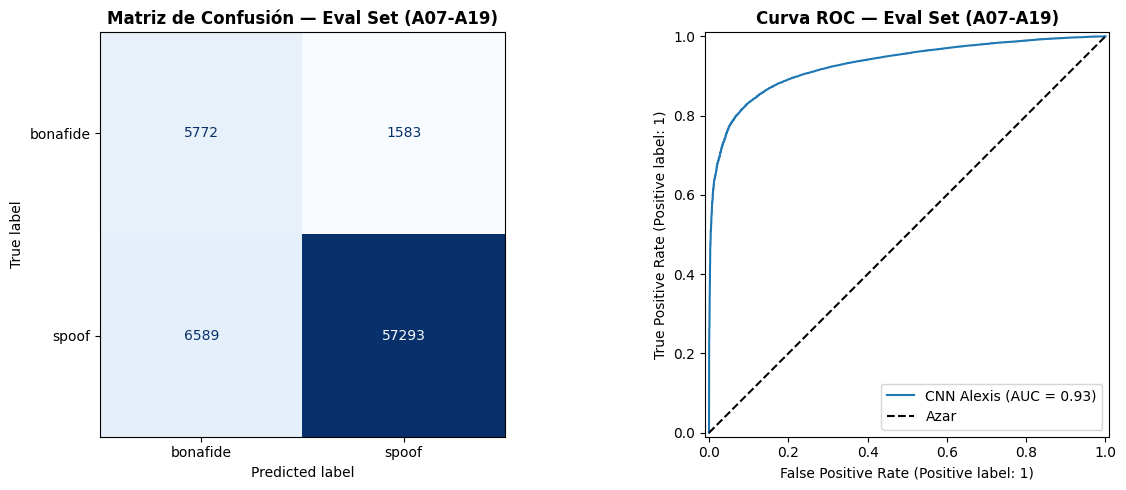

In [ ]:
# Evaluación sobre el conjunto de evaluación (Eval Set) con tipos NO vistos en entrenamiento (A07-A19)
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay
)

# Cargar modelo y tensores del eval set (A07-A19)
model    = tf.keras.models.load_model('../Metricas/ETL_V2.1_train/modelo2_alexis.keras')
X_eval   = np.load('../Metricas/ETL_V2.1_eval/X_fourier_features.npy')
y_eval   = np.load('../Metricas/ETL_V2.1_eval/y_labels.npy')

print(f'Eval set shape: {X_eval.shape}')
print(f'Distribución  : bonafide={( y_eval==0).sum()}  spoof={(y_eval==1).sum()}')

# Adaptar dimensiones igual que en entrenamiento
if len(X_eval.shape) == 5:
    X_eval = X_eval.reshape(-1, *X_eval.shape[2:])
X_eval_cnn = X_eval[..., np.newaxis]

# Predecir
y_prob_eval = model.predict(X_eval_cnn, verbose=1).flatten()
y_pred_eval = (y_prob_eval >= 0.5).astype(int)

# Classification Report
print('\n=== Evaluación sobre EVAL SET (A07-A19) — tipos NO vistos en train ===')
print(classification_report(y_eval, y_pred_eval, target_names=['bonafide', 'spoof']))
print(f'ROC-AUC: {roc_auc_score(y_eval, y_prob_eval):.4f}')

# Matriz de confusión + Curva ROC
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_eval, y_pred_eval),
    display_labels=['bonafide', 'spoof']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusión — Eval Set (A07-A19)', fontweight='bold')

RocCurveDisplay.from_predictions(y_eval, y_prob_eval, ax=axes[1], name='CNN Alexis')
axes[1].plot([0, 1], [0, 1], 'k--', label='Azar')
axes[1].set_title('Curva ROC — Eval Set (A07-A19)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()


### Reentrenamiento del Modelo usando class_weight

Debido a que usando los datos del set EVAL, el rendimiento del modleo bajo, y es particularmente bajo en los datos spoof, vamos a reentrenar el modelo.

El primer cambio al modelo sera aplicar un balanceo de datos usando class_weight. No aplicamos técnicas smooth de oversampling para la clase minoritaria ya que no funciona bien con espectrogramas en formato tensorial (N, 5, 1025, 1), porque SMOTE interpola entre puntos en el espacio de features, lo que destruye la estructura espacial del espectrograma. Y el undersampling no lo aplicaremos ya que el objetivo de este ejercicio es usar todos los datos.

Usando class_weight le diremos al modelo que penalice más los errores en bonafide durante el entrenamiento, sin tocar los datos. De esta forma usaremos todos los datos, contrario a lo que pasaría si usaramos undersamplig.

In [ ]:
# Cálculo de pesos de clase para abordar el desbalanceo en el conjunto de entrenamiento
from sklearn.utils import compute_class_weight
import numpy as np
# El método compute_class_weight calcula automáticamente los pesos inversamente proporcionales a la frecuencia de cada clase.
pesos = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)
class_weights = {0: pesos[0], 1: pesos[1]}
print(f'Peso bonafide (real) : {class_weights[0]:.2f}')
print(f'Peso spoof (falso)   : {class_weights[1]:.2f}')

Peso bonafide (real) : 4.92
Peso spoof (falso)   : 0.56


In [ ]:
# Reentrenamiento del modelo con pesos de clase para mejorar la detección de la clase minoritaria (spoof)
from tensorflow.keras.callbacks import EarlyStopping

# Reconstruir el modelo con la misma arquitectura, pero sin cargar pesos previos para evitar sobreajuste a los datos originales
cnn_model_bal = tf.keras.models.clone_model(cnn_model)
cnn_model_bal.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
# Configuración de EarlyStopping para evitar sobreajuste durante el reentrenamiento
monitor_parada = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)
# Reentrenamiento con pesos de clase
historial_bal = cnn_model_bal.fit(
    X_train_cnn, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_cnn, y_test),
    callbacks=[monitor_parada],
    class_weight=class_weights,
    verbose=1
)
print('\nEntrenamiento completado.')


Epoch 1/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.3814 - auc: 0.6349 - loss: 0.6865 - val_accuracy: 0.4019 - val_auc: 0.7438 - val_loss: 0.5673
Epoch 2/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.3883 - auc: 0.6962 - loss: 0.6013 - val_accuracy: 0.4174 - val_auc: 0.7538 - val_loss: 0.5652
Epoch 3/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.3914 - auc: 0.7295 - loss: 0.5759 - val_accuracy: 0.3977 - val_auc: 0.7870 - val_loss: 0.5526
Epoch 4/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.4844 - auc: 0.7687 - loss: 0.5491 - val_accuracy: 0.7444 - val_auc: 0.8569 - val_loss: 0.5275
Epoch 5/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.7912 - auc: 0.8314 - loss: 0.5008 - val_accuracy: 0.7832 - val_auc: 0.9135 - val_loss: 0.5066
Epoch 6/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8480 - auc: 0.8754 - loss: 0.4421 - val_accuracy: 0.8924 - val_auc: 0.9331 - val_loss: 0.4156
Epoch 7/50
794/794 ━━━━━━━━━

In [ ]:
# Guardar el modelo balanceado
cnn_model_bal.save('../Metricas/ETL_V2.1_train/modelo2_alexis_balanceado.keras')
print('Modelo balanceado guardado.')


Modelo balanceado guardado.


### Evaluación del modelo ya balanceado usando set EVAL

Después de aplicar classweigth como estrategia de balanceo de datos, evaluamos nuemaente el rendimiento del modleo sobre el set EVAL (A7 - A19), esperando que el balanceo haya ayudado al modleo a mejorar su rendimiento sore todo en el conjunto bonafide.

In [16]:
# Evaluación del modelo balanceado en el conjunto de evaluación (A07-A19)
X_eval     = np.load('../Metricas/ETL_V2.1_eval/X_fourier_features.npy')
y_eval     = np.load('../Metricas/ETL_V2.1_eval/y_labels.npy')

if len(X_eval.shape) == 5:
    X_eval = X_eval.reshape(-1, *X_eval.shape[2:])
X_eval_cnn = X_eval[..., np.newaxis]

y_prob_bal = cnn_model_bal.predict(X_eval_cnn, verbose=1).flatten()
y_pred_bal = (y_prob_bal >= 0.5).astype(int)

print('\n=== Modelo BALANCEADO — Eval Set (A07-A19) ===')
print(classification_report(y_eval, y_pred_bal, target_names=['bonafide', 'spoof']))
print(f'ROC-AUC: {roc_auc_score(y_eval, y_prob_bal):.4f}')


2227/2227 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step

=== Modelo BALANCEADO — Eval Set (A07-A19) ===
              precision    recall  f1-score   support

    bonafide       0.48      0.77      0.60      7355
       spoof       0.97      0.91      0.94     63882

    accuracy                           0.89     71237
   macro avg       0.73      0.84      0.77     71237
weighted avg       0.92      0.89      0.90     71237

ROC-AUC: 0.9385


A pesar del balanceo, a primera vista los resultados no tienen una mejora significante. Sin embargo, vamos a comparar los resultados del primer modelo (sin balancer) y el segundo modelo (usando class weight) sobre el set EVAL para compara uno a uno los resultados.

In [20]:
# Comparación de métricas entre el modelo original y el balanceado
import pandas as pd
from sklearn.metrics import f1_score

comparacion = pd.DataFrame([
    {
        'Modelo': 'CNN original (sin balanceo)',
        'ROC-AUC'          : roc_auc_score(y_eval, y_prob_eval),
        'F1-bonafide'      : f1_score(y_eval, y_pred_eval, average=None)[0],
        'F1-spoof'         : f1_score(y_eval, y_pred_eval, average=None)[1],
        'F1-macro'         : f1_score(y_eval, y_pred_eval, average='macro'),
    },
    {
        'Modelo': 'CNN balanceada (class_weight)',
        'ROC-AUC'          : roc_auc_score(y_eval, y_prob_bal),
        'F1-bonafide'      : f1_score(y_eval, y_pred_bal, average=None)[0],
        'F1-spoof'         : f1_score(y_eval, y_pred_bal, average=None)[1],
        'F1-macro'         : f1_score(y_eval, y_pred_bal, average='macro'),
    },
])
print(comparacion.to_string(index=False))


                       Modelo  ROC-AUC  F1-bonafide  F1-spoof  F1-macro
  CNN original (sin balanceo) 0.930222     0.585514  0.933430  0.759472
CNN balanceada (class_weight) 0.938520     0.595236  0.937496  0.766366


Matriz de confusion y curva ROC

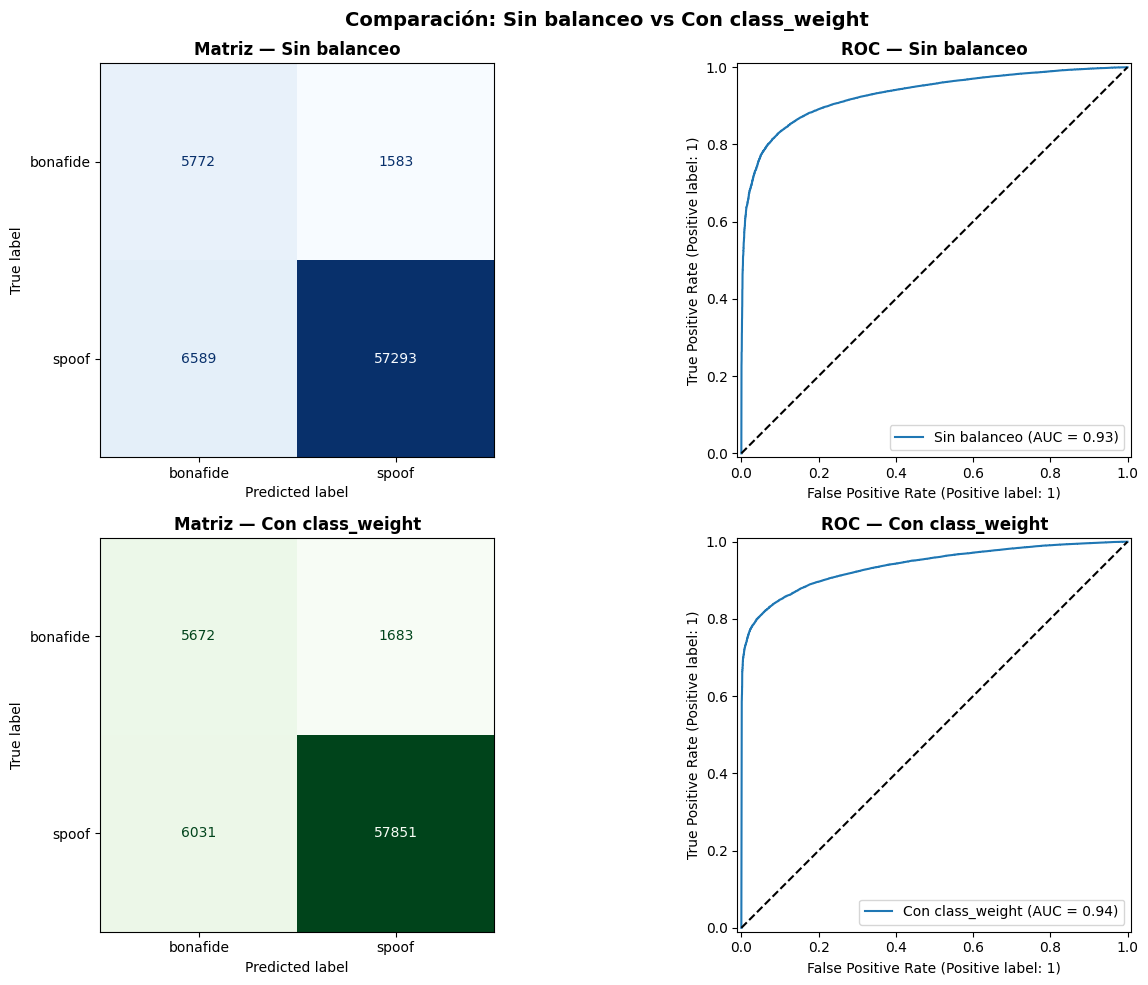

In [21]:
# Comparativa de matrices de confusión y curvas ROC para ambos modelos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Modelo original
ConfusionMatrixDisplay(
    confusion_matrix(y_eval, y_pred_eval),
    display_labels=['bonafide', 'spoof']
).plot(ax=axes[0][0], colorbar=False, cmap='Blues')
axes[0][0].set_title('Matriz — Sin balanceo', fontweight='bold')

RocCurveDisplay.from_predictions(
    y_eval, y_prob_eval, ax=axes[0][1], name='Sin balanceo')
axes[0][1].plot([0, 1], [0, 1], 'k--')
axes[0][1].set_title('ROC — Sin balanceo', fontweight='bold')

# Modelo balanceado
ConfusionMatrixDisplay(
    confusion_matrix(y_eval, y_pred_bal),
    display_labels=['bonafide', 'spoof']
).plot(ax=axes[1][0], colorbar=False, cmap='Greens')
axes[1][0].set_title('Matriz — Con class_weight', fontweight='bold')

RocCurveDisplay.from_predictions(
    y_eval, y_prob_bal, ax=axes[1][1], name='Con class_weight')
axes[1][1].plot([0, 1], [0, 1], 'k--')
axes[1][1].set_title('ROC — Con class_weight', fontweight='bold')

plt.suptitle('Comparación: Sin balanceo vs Con class_weight', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Conclusión

Aunque los resultados mejoraron, esta mejora es mínima; precision bonafide de 0.47 a 0.48. Esto nos lleva a pensar a que el problema no es solo el balanceo, sino que el modelo tiene dificultades para aprender las características de los audios bonafide ya que solo aprendio de 6 tipos de spoof en train y el set de evaluación tiene 13 nuevos tipos.

Vamos a explorar umbrales por encima y por debajo de 0.5.

## Optimización con Umbrales de Desición

Ya que el balanceo usando classweight no mejoró el rendimiento el modelo, trataremos de ajustar el umbral de decision para obligar al modelo a ser más exigente antes de clasificar un audio como spoof, es decir, por encima del 0.5 estándar.b

El modelo devuelve una probabilidad entre 0 y 1 de que el audio sea Spoof. Por defecto, si esta probabilidad supera 0.5, se clasifica como spoof, de lo contrario, como bonafide. Como este corte no siempre es el óptimo cuando hay desbalanceo de clases, probaremos 9 umbrales distintos midiendo las métricas en cada uno para encontrar el que mejor equilibre la deteccion de las dos clases.

In [22]:
# Evaluación de umbrales de decisión para optimizar F1-score en la clase minoritaria spoof
import pandas as pd
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score

resultados_umbral = []
for umbral in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    y_pred_u     = (y_prob_bal >= umbral).astype(int)
    prec_bon     = precision_score(y_eval, y_pred_u, pos_label=0, zero_division=0)
    rec_bon      = recall_score(y_eval, y_pred_u, pos_label=0, zero_division=0)
    f1_bon       = f1_score(y_eval, y_pred_u, pos_label=0, zero_division=0)
    prec_spo     = precision_score(y_eval, y_pred_u, pos_label=1, zero_division=0)
    rec_spo      = recall_score(y_eval, y_pred_u, pos_label=1, zero_division=0)
    f1_spo       = f1_score(y_eval, y_pred_u, pos_label=1, zero_division=0)
    f1_mac       = f1_score(y_eval, y_pred_u, average='macro', zero_division=0)

    resultados_umbral.append({
        'Umbral'        : umbral,
        'Prec-bonafide' : round(prec_bon, 3),
        'Rec-bonafide'  : round(rec_bon, 3),
        'F1-bonafide'   : round(f1_bon, 3),
        'Prec-spoof'    : round(prec_spo, 3),
        'Rec-spoof'     : round(rec_spo, 3),
        'F1-spoof'      : round(f1_spo, 3),
        'F1-macro'      : round(f1_mac, 3),
    })

df_umbrales = pd.DataFrame(resultados_umbral)
print(df_umbrales.to_string(index=False))

# Marcar el mejor umbral por F1-macro
mejor = df_umbrales.loc[df_umbrales['F1-macro'].idxmax()]
print(f'\nMejor umbral por F1-macro: {mejor["Umbral"]}')


 Umbral  Prec-bonafide  Rec-bonafide  F1-bonafide  Prec-spoof  Rec-spoof  F1-spoof  F1-macro
    0.1          0.619         0.398        0.484       0.933      0.972     0.952     0.718
    0.2          0.573         0.527        0.549       0.946      0.955     0.950     0.750
    0.3          0.545         0.619        0.580       0.955      0.940     0.948     0.764
    0.4          0.513         0.694        0.590       0.963      0.924     0.943     0.767
    0.5          0.485         0.771        0.595       0.972      0.906     0.937     0.766
    0.6          0.437         0.855        0.578       0.981      0.873     0.924     0.751
    0.7          0.402         0.909        0.557       0.988      0.844     0.910     0.734
    0.8          0.368         0.946        0.530       0.992      0.813     0.894     0.712
    0.9          0.335         0.975        0.499       0.996      0.777     0.873     0.686

Mejor umbral por F1-macro: 0.4


=== Evaluación final con umbral 0.4 ===
              precision    recall  f1-score   support

    bonafide       0.51      0.69      0.59      7355
       spoof       0.96      0.92      0.94     63882

    accuracy                           0.90     71237
   macro avg       0.74      0.81      0.77     71237
weighted avg       0.92      0.90      0.91     71237

ROC-AUC: 0.9385


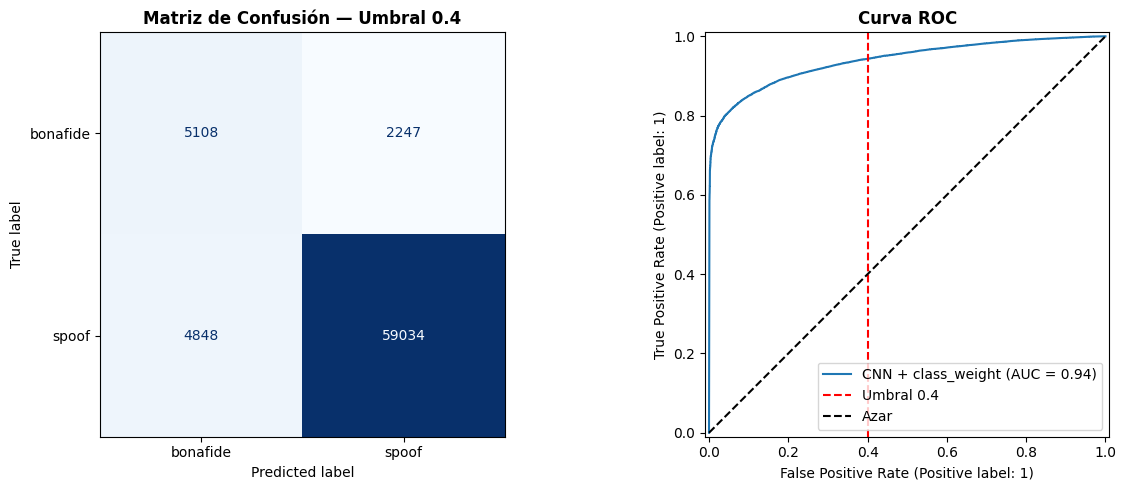


=== Resumen comparativo ===
                         Modelo  F1-bonafide  F1-spoof  ROC-AUC
      CNN original (umbral 0.5)     0.590000  0.930000  0.93020
CNN + class_weight (umbral 0.5)     0.600000  0.930000  0.93850
CNN + class_weight (umbral 0.4)     0.590145  0.943314  0.93852


In [23]:
# Aplicamos el umbral óptimo para obtener la clasificación final
UMBRAL_OPTIMO = 0.4
y_pred_final = (y_prob_bal >= UMBRAL_OPTIMO).astype(int)

print('=== Evaluación final con umbral 0.4 ===')
print(classification_report(y_eval, y_pred_final, target_names=['bonafide', 'spoof']))
print(f'ROC-AUC: {roc_auc_score(y_eval, y_prob_bal):.4f}')

# Matriz de confusión + ROC
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_eval, y_pred_final),
    display_labels=['bonafide', 'spoof']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusión — Umbral 0.4', fontweight='bold')

RocCurveDisplay.from_predictions(y_eval, y_prob_bal, ax=axes[1], name='CNN + class_weight')
axes[1].axvline(x=0.4, color='red', linestyle='--', label='Umbral 0.4')
axes[1].plot([0, 1], [0, 1], 'k--', label='Azar')
axes[1].set_title('Curva ROC', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

# Resumen comparativo final
print('\n=== Resumen comparativo ===')
resumen = pd.DataFrame([
    {'Modelo': 'CNN original (umbral 0.5)',        'F1-bonafide': 0.59, 'F1-spoof': 0.93, 'ROC-AUC': 0.9302},
    {'Modelo': 'CNN + class_weight (umbral 0.5)',  'F1-bonafide': 0.60, 'F1-spoof': 0.93, 'ROC-AUC': 0.9385},
    {'Modelo': 'CNN + class_weight (umbral 0.4)',
     'F1-bonafide': f1_score(y_eval, y_pred_final, pos_label=0),
     'F1-spoof'   : f1_score(y_eval, y_pred_final, pos_label=1),
     'ROC-AUC'    : roc_auc_score(y_eval, y_prob_bal)},
])
print(resumen.to_string(index=False))


## Conclusiones del Análisis de Umbral

Tratando de mejorar como el modelo clasifica los audios bonafide, se evaluaron diferentes umbrales de decisión, de 0.1 a 0.9.

**Resultados:**

| Configuración | Precision bonafide | Recall bonafide | F1-bonafide | ROC-AUC |
|---|---|---|---|---|
| CNN original (umbral 0.5) | 0.47 | 0.78 | 0.59 | 0.9302 |
| CNN + class_weight (umbral 0.5) | 0.48 | 0.77 | 0.60 | 0.9385 |
| CNN + class_weight (umbral 0.4) | 0.51 | 0.68 | 0.58 | 0.9385 |

**Decisión:** Se mantiene el umbral 0.5 porque el recall de bonafide 
es la métrica más crítica para el caso de uso que nos planteamos en telefonica; dejar pasar una llamada falsa es más peligroso que bloquear una real por error.

**Limitación principal:** El modelo fue entrenado con solo 6 sistemas 
de spoof (A01-A06) y evaluado contra 13 nuevos (A07-A19). La mejora 
real requeriría más datos de audio bonafide en entrenamiento.

Podriamos tratar el oversampling de la clase minoritaria, sin embargo como el data set que estamos usando trabaja con tensores de Fourier y no con features numéricas simples, esto no funcionaria bien porque interpolar espectrogramas, genera imágenes espectrales que no corresponden a ningún audio real.


## Data Augmentation sobre Bonafide

Debido a que los intentos anteriores aplicando class weight y ajuste del umbral no funcionaron, trataremos hacer un data augmentation sobre los datos bonafide para que el modelo tenga mas ejemplos reales con los que pueda aprender. 

Con esta técnica se crean copias modificadas de bonafide en el data set, tomando espectrogramas bonafide reales al azar y añadiendo ruido gaussiano muy pequeño (factor_ruido=0.01): pequeñas variaciones aleatorias en la magnitud de cada frecuencia, para que el modelo lo trate como un ejemplo nuevo pero sin alterar la firma acústica real de la voz.

In [ ]:
# Data Augmentation para la clase minoritaria bonafide utilizando ruido gaussiano
import numpy as np

# Separar bonafide y spoof del train
X_bon  = X_train_cnn[y_train == 0]
X_spo  = X_train_cnn[y_train == 1]
y_bon  = y_train[y_train == 0]
y_spo  = y_train[y_train == 1]

# Verificar el desbalance original, calculando cuántos bonafide faltan para igualar 
# la cantidad de spoof 
print(f'Bonafide original : {len(X_bon)}')
print(f'Spoof original    : {len(X_spo)}')

# Función de aumento de datos: se crean copias modificadas de bonafide existentes y agrega ruido 
# gaussiano a los espectrogramas para simular variaciones naturales en las grabaciones.
def augmentar_espectrograma(X, factor_ruido=0.01):
    ruido = np.random.normal(0, factor_ruido, X.shape)
    return np.clip(X + ruido, 0, None)  # espectrogramas no tienen valores negativos

# Generar suficientes bonafide para igualar spoof
n_necesarios = len(X_spo) - len(X_bon)
indices_aug  = np.random.choice(len(X_bon), size=n_necesarios, replace=True)
X_bon_aug    = augmentar_espectrograma(X_bon[indices_aug])
y_bon_aug    = np.zeros(len(X_bon_aug), dtype=y_train.dtype)

# Combinar originales + aumentados
X_train_aug = np.concatenate([X_train_cnn, X_bon_aug])
y_train_aug = np.concatenate([y_train, y_bon_aug])

# Mezclar aleatoriamente
idx_shuffle = np.random.permutation(len(X_train_aug))
X_train_aug = X_train_aug[idx_shuffle]
y_train_aug = y_train_aug[idx_shuffle]

print(f'\nTras augmentation:')
print(f'  bonafide : {(y_train_aug == 0).sum()}')
print(f'  spoof    : {(y_train_aug == 1).sum()}')
print(f'  total    : {len(X_train_aug)}')


Bonafide original : 2580
Spoof original    : 22800

Tras augmentation:
  bonafide : 22800
  spoof    : 22800
  total    : 45600


### Reentrenamiento del modelo despues del Data Augmentation

In [25]:
# Reentrenamiento del modelo con pesos de clase para mejorar la detección de la clase minoritaria (spoof)
from tensorflow.keras.callbacks import EarlyStopping

cnn_model_aug = tf.keras.models.clone_model(cnn_model)
cnn_model_aug.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

monitor = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

historial_aug = cnn_model_aug.fit(
    X_train_aug, y_train_aug,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_cnn, y_test),
    callbacks=[monitor],
    verbose=1
)
print('\nEntrenamiento completado.')


Epoch 1/50
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7900 - auc: 0.8852 - loss: 0.4243 - val_accuracy: 0.6609 - val_auc: 0.7690 - val_loss: 0.9841
Epoch 2/50
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.9366 - auc: 0.9781 - loss: 0.1718 - val_accuracy: 0.9012 - val_auc: 0.8975 - val_loss: 0.2427
Epoch 3/50
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.9497 - auc: 0.9881 - loss: 0.1294 - val_accuracy: 0.3660 - val_auc: 0.7635 - val_loss: 4.0785
Epoch 4/50
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9537 - auc: 0.9913 - loss: 0.1125 - val_accuracy: 0.9289 - val_auc: 0.9366 - val_loss: 0.1792
Epoch 5/50
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.9629 - auc: 0.9939 - loss: 0.0928 - val_accuracy: 0.9344 - val_auc: 0.9581 - val_loss: 0.1755
Epoch 6/50
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.9684 - auc: 0.9953 - loss: 0.0811 - val_accuracy: 0.9216 - val_auc: 0.9302 - val_loss: 0.2218
Epoch 7/50
1425/

In [26]:
# Guardar el modelo entrenado con data augmentation
cnn_model_aug.save('../Metricas/ETL_V2.1_train/modelo2_alexis_augmented.keras')
print('Modelo guardado.')

Modelo guardado.


### Evaluacion del modleo usando el set EVAL

In [27]:
# Evaluación del modelo con data augmentation en el conjunto de evaluación (A07-A19)
y_prob_aug = cnn_model_aug.predict(X_eval_cnn, verbose=1).flatten()
y_pred_aug = (y_prob_aug >= 0.5).astype(int)

print('\n=== Modelo con Data Augmentation — Eval Set (A07-A19) ===')
print(classification_report(y_eval, y_pred_aug, target_names=['bonafide', 'spoof']))
print(f'ROC-AUC: {roc_auc_score(y_eval, y_prob_aug):.4f}')


2227/2227 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step

=== Modelo con Data Augmentation — Eval Set (A07-A19) ===
              precision    recall  f1-score   support

    bonafide       0.49      0.76      0.60      7355
       spoof       0.97      0.91      0.94     63882

    accuracy                           0.89     71237
   macro avg       0.73      0.83      0.77     71237
weighted avg       0.92      0.89      0.90     71237

ROC-AUC: 0.9368


### Comparación de Metricas usando el modleo original, class weight y data agmentation)

In [ ]:
# Comparación de métricas entre el modelo balanceado y el modelo con data augmentation
resumen = pd.DataFrame([
    {
        'Modelo'        : 'CNN original',
        'F1-bonafide'   : f1_score(y_eval, y_pred_eval, pos_label=0),
        'Recall-bon'    : recall_score(y_eval, y_pred_eval, pos_label=0),
        'Precision-bon' : precision_score(y_eval, y_pred_eval, pos_label=0),
        'F1-spoof'      : f1_score(y_eval, y_pred_eval, pos_label=1),
        'ROC-AUC'       : roc_auc_score(y_eval, y_prob_eval),
    },
    {
        'Modelo'        : 'CNN + class_weight',
        'F1-bonafide'   : f1_score(y_eval, y_pred_bal, pos_label=0),
        'Recall-bon'    : recall_score(y_eval, y_pred_bal, pos_label=0),
        'Precision-bon' : precision_score(y_eval, y_pred_bal, pos_label=0),
        'F1-spoof'      : f1_score(y_eval, y_pred_bal, pos_label=1),
        'ROC-AUC'       : roc_auc_score(y_eval, y_prob_bal),
    },
    {
        'Modelo'        : 'CNN + data augmentation',
        'F1-bonafide'   : f1_score(y_eval, y_pred_aug, pos_label=0),
        'Recall-bon'    : recall_score(y_eval, y_pred_aug, pos_label=0),
        'Precision-bon' : precision_score(y_eval, y_pred_aug, pos_label=0),
        'F1-spoof'      : f1_score(y_eval, y_pred_aug, pos_label=1),
        'ROC-AUC'       : roc_auc_score(y_eval, y_prob_aug),
    },
])
print(resumen.round(4).to_string(index=False))


                 Modelo  F1-bonafide  Recall-bon  Precision-bon  F1-spoof  ROC-AUC
           CNN original       0.5855      0.7848         0.4670    0.9334   0.9302
     CNN + class_weight       0.5952      0.7712         0.4847    0.9375   0.9385
CNN + data augmentation       0.5954      0.7608         0.4891    0.9385   0.9368


Dado que la estrategia de data augmentation tampoco mejoro significativamente los resultados, vamos a analizar el número y tipo de voces que tiene el set de entrenamiento y evaluación para verificar si hay una gran diferencia y esto pueda ser la causa que los resultados no mejoran significativamente.

In [ ]:
# Análisis de hablantes y ataques presentes en los protocolos de entrenamiento y evaluación
import pandas as pd

# Cargar protocolo de train
protocol_train = pd.read_csv(
    '../data/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt',
    sep=' ', header=None,
    names=['speaker', 'file_name', 'env', 'attack', 'label']
)

# Cargar protocolo de eval
protocol_eval = pd.read_csv(
    '../data/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt',
    sep=' ', header=None,
    names=['speaker', 'file_name', 'env', 'attack', 'label']
)

# Hablantes bonafide en train
bon_train = protocol_train[protocol_train['label'] == 'bonafide']
bon_eval  = protocol_eval[protocol_eval['label'] == 'bonafide']

hablantes_train = set(bon_train['speaker'].unique())
hablantes_eval  = set(bon_eval['speaker'].unique())
hablantes_comunes = hablantes_train & hablantes_eval

print(f'Hablantes bonafide en train         : {len(hablantes_train)}')
print(f'Hablantes bonafide en eval          : {len(hablantes_eval)}')
print(f'Hablantes en común (train y eval)   : {len(hablantes_comunes)}')
print(f'Hablantes nuevos solo en eval       : {len(hablantes_eval - hablantes_train)}')

print(f'\nSistemas spoof en train : {sorted(bon_train["attack"].unique())}')
print(f'Sistemas spoof en train : {sorted(protocol_train[protocol_train["label"]=="spoof"]["attack"].unique())}')
print(f'Sistemas spoof en eval  : {sorted(protocol_eval[protocol_eval["label"]=="spoof"]["attack"].unique())}')


Hablantes bonafide en train         : 20
Hablantes bonafide en eval          : 67
Hablantes en común (train y eval)   : 0
Hablantes nuevos solo en eval       : 67

Sistemas spoof en train : ['-']
Sistemas spoof en train : ['A01', 'A02', 'A03', 'A04', 'A05', 'A06']
Sistemas spoof en eval  : ['A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19']


## Conclusiones Finales - Análisis de Estrategias de Balanceo — Eval Set (A07-A19)

### Resultados comparativos

| Modelo | F1-bonafide | Recall-bon | Precision-bon | F1-spoof | ROC-AUC |
|--------|-------------|------------|---------------|----------|---------|
| CNN original | 0.5855 | 0.7848 | 0.4670 | 0.9334 | 0.9302 |
| CNN + class_weight | 0.5952 | 0.7712 | 0.4847 | 0.9375 | 0.9385 |
| CNN + data augmentation | 0.5954 | 0.7608 | 0.4891 | 0.9385 | 0.9368 |

Los tres modelos probados son muy similares y la mejora en cada uno no es significativa. Por lo que concluimos que el problema de fondo no radica en el balanceo sino en la limitación de los datos de bonafide, ya que el modelo entrena con audios bonafide de solo 20 hablantes en codiciones controladas. Sin embargo, el set eval tiene hablantes y condiciones diferentes, este gap no es posible achicarlo usando ninguna de las téctivcas de balanceo probadas.

### Análisis

- **CNN original:** mejor recall bonafide (0.78) — detecta más audios reales 
- **CNN + class_weight:** sube precision pero baja recall
- **CNN + data augmentation:** agregar ruido no aporta información nueva

### Conclusión

Mantendremos el modelo original como modelo final. Los modelos con balanceo
mejoran levemente la precision de bonafide pero a costa de un recall más bajo, lo cual no nos aparta mejoria para nuestro caso de uso de telefonica, que seria detectar llamadas falsas y dejar pasar una llamada falsa
es más peligroso que bloquear una real por error.

### Limitación identificada

El análisis de ASVspoof 2019 nos muestra la causa raíz:

| | Train | Eval |
|--|--|--|
| Hablantes bonafide | 20 | 67 |
| Hablantes en común | 0 | — |
| Sistemas spoof | A01-A06 | A07-A19 |

Como mencionamos anteriormente, el modelo nunca vio alguno de los 67 hablantes del set eval durante el entrenamiento, ni ninguno de los 13 sistemas de spoof evaluados. Esta gap no va amejorar usando técnicas de balanceo sino que necesitamos datos de entrenamiento con más diversidad de hablantes y tipos.

Lo siguiente que podríamos hacer sería usar el set eval para entrenamiento, pero necesitariamos un tercer conjunto de datos para evaluar. Sin embargo, al hacer esto tememos que caigamos en un loop, ya que siempre serian datos en un nuevo set de eval no vistos y requeririamos un poder de computo mas y mas grande al integrar más y más datos.  
